# [STARE] UNet -- SPLIT TESTS #3 -- LOO AGG FOLD LOOPS -- seed 1337

In [ ]:
from pathlib import Path
import torch
torch.cuda.set_device(1)          # pin this kernel to GPU 1
DEVICE = torch.device('cuda:1')

In [ ]:
import sys, os
sys.path.append(os.path.abspath('../../'))

In [ ]:
from src.models.unet import UNet
print(UNet)

<class 'src.models.unet.UNet'>


# CHANGE THESE

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED   = 1337
DATASET = "STARE" # "DRIVE" | "STARE" | "CHASEDB1"

PATCH_SIZE = 128
VAL_WINDOW  = PATCH_SIZE
VAL_OVERLAP = 0.25

VESSEL_BIAS=0.7
MIN_PERCENT_VESSEL=0.008
V_MULT=30
DENSE_BIAS=None
BATCH_SIZE=2

IMG_SIZE=512

EPOCHS = 50
warmup_epochs = 5

FOLDS = 10
FOLD_ID = 0

THRESHOLD_EVAL = 0.5


MODEL_NAME = "UNet"
TITLE     = f"[{DATASET}] {MODEL_NAME} NEW SPLIT ({FOLDS} folds) -- seed 1337 -- DPCN 6x64 hl=2 reduce=64 cbam=16 epochs={EPOCHS}"
SAVE_ROOT = Path(f"../../../../pth/{MODEL_NAME}_{DATASET}_NEWSPLIT")     # a clean experiment folder
SAVE_CKPT = SAVE_ROOT / "checkpoints"
SAVE_PRED = SAVE_ROOT / "predictions"   # per-image logits/prob/masks
SAVE_VIZ  = SAVE_ROOT / "visuals"       # PNG overlays per test image
SAVE_LOGS = SAVE_ROOT / "logs"
for d in [SAVE_ROOT, SAVE_CKPT, SAVE_PRED, SAVE_VIZ, SAVE_LOGS]: d.mkdir(parents=True, exist_ok=True)

DATASET_ROOT        = f"../../../../Retinal_Vessel_Segmentation_Datasets/{DATASET}/"
DATASET_LABELFOLDER = "1st_manual"




# IMPORTS

In [ ]:
import os, json, math, time, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import LambdaLR
import matplotlib.pyplot as plt

# --- data utils ---
from src.data.splits import (
    split_drive_20_20,
    split_chase_subjectwise_20_8,
    split_stare_leave_one_out,
    stare_loo_fold,

    drive_random_20_20,

    chase_random_subject_split,

)

from src.data.dataloader import make_loaders
from src.data.augmentations import get_train_augs, get_val_augs

# use YOUR metrics utilities
from src.training.metrics import (
    confusion_counts,
    dice as dice_metric,
    iou as iou_metric,
    roc_auc as roc_auc_metric,
    pr_auc as pr_auc_metric,
    acc_from_counts,
    recall_from_counts,          # sensitivity
    specificity_from_counts,     # specificity
    cldice
)



# --- evaluation & visualization ---
from src.evaluation.evaluate import evaluate_and_print
from src.evaluation.visualization import visualize_samples

In [ ]:
def eval_leftout_with_fov(prob_1chw: torch.Tensor,
                          gt_1chw: torch.Tensor,
                          fov_1chw: torch.Tensor,
                          thr: float = 0.5) -> dict:
    """
    Evaluate one test image (left out) using *your* metrics helpers.
    All metrics are computed *within FOV*.
    """
    # to cpu numpy
    p = prob_1chw.squeeze().detach().cpu().numpy()       # [H,W] probs in [0,1]
    g = gt_1chw.squeeze().detach().cpu().numpy()         # [H,W] {0,1}
    f = fov_1chw.squeeze().detach().cpu().numpy()        # [H,W] {0,1}

    # clamp to FOV (zero-out everything outside)
    p_f = p * (f > 0.5)
    g_f = (g > 0.5).astype(np.uint8)

    # binarize at thr (inside FOV)
    pred_f = (p_f >= thr).astype(np.uint8)

    # counts + derived metrics
    tp, fp, tn, fn = confusion_counts(pred_f, g_f)

    ACC  = float(acc_from_counts(tp, fp, tn, fn))
    SEN  = float(recall_from_counts(tp, fn))        # sensitivity / TPR
    SPE  = float(specificity_from_counts(tn, fp))
    DICE = float(dice_metric(pred_f, g_f))
    IOU  = float(iou_metric(pred_f, g_f))
    CLDICE = float(cldice(pred_f, g_f))

    # probability-based (AUCs) computed on FOV-masked prob/gt
    try:
        AUC = float(roc_auc_metric(p_f, g_f))
    except Exception:
        AUC = float("nan")
    try:
        AP = float(pr_auc_metric(p_f, g_f))
    except Exception:
        AP = float("nan")

    return dict(ACC=ACC, Dice=DICE, IoU=IOU, SEN=SEN, SPE=SPE, AUC=AUC, AP=AP,CLDICE=CLDICE,
                tp=int(tp), fp=int(fp), tn=int(tn), fn=int(fn))



# helpers and config

In [ ]:
os.getcwd()

'c:\\Users\\s1005\\OneDrive\\文件\\PLM_DOCS\\code\\githubs\\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\\notebooks\\train_all'

In [ ]:
# --- model factory (fresh per fold) ---
from src.models.wrappers.dpcn_concat_unet import DPCNConcatUNet
BASE_KW = {"cbam_reduction": 16}

def make_model(MODEL_NAME, train_loader = None) -> nn.Module:
    if MODEL_NAME == "MATHFI":
        # --- loss ---
        from src.training.loss_functions import DiceBCEComplementLoss

        def estimate_class_weights(loader, max_batches=20):
            with torch.no_grad():
                s = 0.0; n = 0
                for i, b in enumerate(loader):
                    s += b["mask"].float().mean().item(); n += 1
                    if i+1 >= max_batches: break
            p = max(1e-6, min(1-1e-6, s / max(1, n)))
            w1 = 1.0 / p; w0 = 1.0 / (1.0 - p)
            s2 = w0 + w1; w0 = 2.0 * w0 / s2; w1 = 2.0 * w1 / s2
            return w0, w1

        w0, w1 = estimate_class_weights(train_loader, max_batches=20)
        loss_fn = DiceBCEComplementLoss(w0=w0, w1=w1, dice_weight=0.5, bce_weight=0.5,
                                        exact_equation=False, reduction="mean")

        # --- model ---
        return DPCNConcatUNet(
            in_ch=1, enh_channels=64, iters=6,
            threshold_mode="scaled_vat", half_life=2.0,
            reduce_to=64, base_kwargs=BASE_KW
        ).to(DEVICE), loss_fn

    elif MODEL_NAME == "FR-UNet":
        loss_fn = nn.BCEWithLogitsLoss()
        from models.fr_unet import FR_UNet
        return FR_UNet().to(DEVICE), loss_fn

    elif MODEL_NAME == "UNet":
        from src.models.orig_unet import UNet
        class_weights = torch.tensor([1.30, 1.70], device=DEVICE)  # was ~[1.55,1.65] → ease BG tilt
        loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)  # no label_smoothing

        return UNet(in_channels=1, out_channels=2).to(DEVICE), loss_fn

import torch
import torch.nn.functional as F

@torch.no_grad()
def _get_logits_from_out(out):
    # Accept dict / tuple / list / tensor
    if isinstance(out, dict): out = out.get("logits", out[next(iter(out))])
    if isinstance(out, (list, tuple)): out = out[-1]
    return out

def _center_crop_to(x, size_hw):
    h, w = x.shape[-2:]
    th, tw = size_hw
    if (h, w) == (th, tw):
        return x
    i = max(0, (h - th)//2)
    j = max(0, (w - tw)//2)
    return x[..., i:i+th, j:j+tw]

def _hann2d(win):
    # 2D Hann window in fp32 for smooth blending
    h1 = torch.hann_window(win, periodic=False, dtype=torch.float32)
    w1 = torch.hann_window(win, periodic=False, dtype=torch.float32)
    w2d = torch.outer(h1, w1)
    # normalize to max=1
    w2d = w2d / (w2d.max().clamp_min(1e-8))
    return w2d[None, None]  # [1,1,win,win]

def _tile_starts(L, window, step):
    if L <= window:
        return [0]
    starts = list(range(0, L - window, step))
    if starts[-1] != L - window:
        starts.append(L - window)
    return starts

@torch.no_grad()
def sliding_window_forward_logits_unet(model, img_1chw, window=512, overlap=0.5, device="cuda"):
    """
    img_1chw: [1, C_in, H, W]
    Returns:  [1, C_out, H, W] logits (fp32)
    """
    assert img_1chw.ndim == 4 and img_1chw.shape[0] == 1
    model.eval()

    img = img_1chw.to(device, non_blocking=True)
    _, _, H, W = img.shape
    step = max(1, int(window * (1 - overlap)))

    # If image smaller than window, pad reflectively so tiles are valid
    pad_top = pad_left = pad_bot = pad_right = 0
    if H < window or W < window:
        need_h = max(0, window - H)
        need_w = max(0, window - W)
        pad_top  = need_h // 2
        pad_bot  = need_h - pad_top
        pad_left = need_w // 2
        pad_right= need_w - pad_left
        img = F.pad(img, (pad_left, pad_right, pad_top, pad_bot), mode="reflect")
        _, _, H, W = img.shape

    y_starts = _tile_starts(H, window, step)
    x_starts = _tile_starts(W, window, step)

    weight = _hann2d(window).to(device)                      # [1,1,win,win]
    acc    = None                                            # [1,C_out,H,W] fp32
    wsum   = torch.zeros((1, 1, H, W), device=device, dtype=torch.float32)

    amp = (device == "cuda")
    for y0 in y_starts:
        for x0 in x_starts:
            tile = img[:, :, y0:y0+window, x0:x0+window]     # [1,C_in,win,win]
            with torch.amp.autocast(device_type="cuda", enabled=amp):
                out   = model(tile)
                logits_tile = _get_logits_from_out(out)      # [1,C_out,*,*]

            # If UNet returns slightly different spatial size, center-crop back
            if logits_tile.shape[-2:] != (window, window):
                logits_tile = _center_crop_to(logits_tile, (window, window))

            # accumulate in fp32 for stability
            logits_tile = logits_tile.float()
            if acc is None:
                acc = torch.zeros((1, logits_tile.shape[1], H, W), device=device, dtype=torch.float32)

            acc[:, :, y0:y0+window, x0:x0+window] += logits_tile * weight
            wsum[:, :, y0:y0+window, x0:x0+window] += weight

    logits = acc / wsum.clamp_min(1e-8)                      # [1,C_out,H,W] fp32

    # remove padding if we added it
    if pad_top or pad_left or pad_bot or pad_right:
        logits = logits[:, :, pad_top:H-pad_bot, pad_left:W-pad_right]

    return logits

@torch.no_grad()
def infer_full_logits(model, img_1chw, device, window, overlap):
    return sliding_window_forward_logits_unet(model, img_1chw, window=window, overlap=overlap, device=device)


def add_metrics(model_name, root, label_folder, img_size, ckpt_path, threshold_eval, all_metrics):

        model, _ = make_model(model_name)
        stem = Path(ckpt_path).stem  # "STARE_fold00"
        fold_id = int(stem.split("fold")[-1])  # 0
        #print(f"checkpoint_path: {ckpt_path}\nfold_id:{fold_id}")

        _, te_pairs = stare_loo_fold(root, label_folder=label_folder, fold_id=fold_id)

        _, test_loader = make_loaders(
            train_pairs=te_pairs, val_pairs=te_pairs,
            image_size=img_size, batch_size=1, num_workers=1,
            seed=SEED, strict_fov=True,
            augs_train=None, augs_val=get_val_augs(img_size),
        )
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        model.eval()

        batch = next(iter(test_loader))
        x   = batch["image"].to(DEVICE)
        y   = batch["mask"].to(DEVICE)
        fov = batch.get("fov", torch.ones_like(y)).to(DEVICE)
        img_path = batch["image_path"][0]
        img_stem = Path(img_path).stem

        logits = infer_full_logits(model, x, window=VAL_WINDOW, overlap=VAL_OVERLAP, device=DEVICE)
        probs = torch.softmax(logits, dim=1)     # [B, 2, H, W]
        prob = probs[:, 1:2, :, :]            # [B, 1, H, W]  vessel probability
        binm = (prob >= threshold_eval).float()      # [B, 1, H, W]

        # 6a) metrics
        # 6a) metrics — use YOUR metrics module via our wrapper
        m = eval_leftout_with_fov(prob[0,0], y[0,0], fov[0,0], thr=threshold_eval)
        m["fold_id"]  = fold_id
        m["image_id"] = img_stem
        all_metrics.append(m)

        def _fmt(v):  # pretty-print, handles NaN
            try:
                return f"{v:.4f}" if v == v else "nan"
            except Exception:
                return str(v)

        print(
            f"== [F{fold_id:02d}] {img_stem} == \n"
            + "\n".join([f"{k}={_fmt(m[k])}" for k in ["SEN","SPE", "CLDICE", "ACC","Dice","IoU","AUC"]])
        )


# --- tiny metric collector (use yours if evaluate_and_print returns a dict) ---
from sklearn.metrics import roc_auc_score, average_precision_score


# --- DATASET HYPERPARAM SCHEDULERS ---
def sched_vessel_bias(epoch):
    if epoch <= 10: return 0.70
    if epoch <= 35: return 0.60
    return 0.50

def sched_min_percent_vessel(epoch):
    if epoch <= 10: return 0.008
    if epoch <= 35: return 0.010
    return 0.008

def sched_patch_size(epoch):
    return 160 if epoch > 45 else 128

# ---- single updater ----
def update_dataset(ds, epoch):
    ds.vessel_bias_p      = sched_vessel_bias(epoch)
    ds.min_percent_vessel = sched_min_percent_vessel(epoch)
    ds.patch_size         = sched_patch_size(epoch)


# --- training boilerplate (pass FOV into the model so DPCN can clamp each iter) ---
def train_one_epoch(model, loader, optimizer, scaler, loss_fn):
    model.train()
    total, n = 0.0, 0
    for batch in loader:
        x = batch["image"].to(DEVICE, non_blocking=True)  # [B,1,H,W]
        y = batch["mask"].to(DEVICE, non_blocking=True)
        if y.dim() == 4 and y.size(1) == 1:   # [B,1,H,W] -> [B,H,W]
            y = y.squeeze(1)
        # If labels are 0/255, uncomment:
        # y = (y > 127).long()
        y = y.long()

        # Optional: mask labels outside FOV if present (keeps loss fair)
        if "fov" in batch:
          fov = batch["fov"].to(DEVICE, non_blocking=True)
          if fov.dim() == 4 and fov.size(1) == 1:
              fov = fov.squeeze(1)
          y = y.clone()
          y[fov <= 0.5] = 255   # ignore_index

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type="cuda", enabled=(DEVICE=="cuda")):
            logits = model(x)          # ← PURE UNET: no fov passed
            y_idx  = prepare_target_for_ce(y, logits)     # (N,H,W) int64
            loss   = loss_fn(logits, y_idx)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()


        total += loss.item() * x.size(0)
        n     += x.size(0)


    return total / max(1, n)

@torch.no_grad()
def validate_loss_only(model, loader, loss_fn,  window, overlap, device=DEVICE,):
    model.eval()
    total, n = 0.0, 0
    for batch in loader:
        x = batch["image"].to(device, non_blocking=True)  # [B,1,H,W] (full images)
        y = batch["mask"].to(device,  non_blocking=True)
        fov = batch.get("fov", torch.ones_like(y)).to(device, non_blocking=True)

        for i in range(x.size(0)):
            # stitch logits over full image i
            logits_i = sliding_window_forward_logits_unet(model, x[i:i+1], window=window, overlap=overlap, device=device)
            # restrict loss to FOV (keeps loss fair)
            yi = y[i:i+1]
            yi = yi * (fov[i:i+1] > 0.5).float()

                # make CE-friendly target
            if yi.dim() == 4 and yi.size(1) == 1:   # [B,1,H,W] -> [B,H,W]
                yi = yi.squeeze(1)
            yi = yi.long()                           # CE requires integer class indices

            with torch.amp.autocast(device_type="cuda", enabled=(device=="cuda")):
                y_idx  = prepare_target_for_ce(yi, logits_i)     # (N,H,W) int64
                loss_i = loss_fn(logits_i, y_idx)

            total += loss_i.item()
            n     += 1
    return total / max(1, n)

def atomic_torch_save(state, path: Path):
    path = Path(path); tmp = path.with_suffix(path.suffix + ".partial")
    try: tmp.unlink()
    except FileNotFoundError: pass
    with open(tmp, "wb") as f:
        torch.save(state, f); f.flush(); os.fsync(f.fileno())
    os.replace(tmp, path)


def prepare_target_for_ce(y, logits):
    # y: (N,1,H,W) or (N,H,W) with 0/255 or floats
    if y.dim() == 4 and y.shape[1] == 1:
        y = y[:, 0]                    # -> (N,H,W)
    if y.dtype.is_floating_point:
        y = (y > 0.5).to(torch.long)   # handle normalized masks
    else:
        y = (y > 0).to(torch.long)     # map 255->1
    C = logits.shape[1]
    assert C == 2, f"Expected 2 classes, got {C}"
    return y



# MAIN RUN

In [ ]:
# --- main LOO run ---
def run_stare_loo_experiment(
    root=DATASET_ROOT, label_folder=DATASET_LABELFOLDER, epochs=EPOCHS, warmup=warmup_epochs, V_MULT=V_MULT,
    batch_size=BATCH_SIZE, img_size=IMG_SIZE, patch_train=True, patch_size=PATCH_SIZE, vessel_bias_p=VESSEL_BIAS,
    threshold_eval=THRESHOLD_EVAL, folds=FOLDS, fold_id=0, chckpnt_paths=None
):
    rng = np.random.RandomState(SEED)
    all_metrics = []
    per_image_preds = {}   # img_stem -> dict(prob_path, bin_path, fold_id)

    while fold_id < folds:

        # add checkpoint paths to metric list
        if chckpnt_paths:
            for ckpt in chckpnt_paths:
                add_metrics(MODEL_NAME,
                            DATASET_ROOT,
                            DATASET_LABELFOLDER,
                            img_size, ckpt,
                            threshold_eval, all_metrics)
            chckpnt_paths.clear()

        print(f"\n========== {MODEL_NAME} {DATASET} NEW SPLIT, Fold {fold_id+1}/{folds} ==========")

        # 1) split
        tr_pairs, te_pairs = stare_loo_fold(root, label_folder=label_folder, fold_id=fold_id)
        # 2) carve val deterministically from the 19 train images (e.g., last 3)
        val_pairs = tr_pairs[-3:]
        tr_pairs_ = tr_pairs[:-3]

        # 3) loaders
        train_loader, val_loader = make_loaders(
            train_pairs=tr_pairs_, val_pairs=val_pairs,
            image_size=img_size, batch_size=batch_size, num_workers=1,
            seed=SEED + fold_id, strict_fov=True,
            augs_train=get_train_augs(img_size),
            augs_val=get_val_augs(img_size),
            patch_train=patch_train, patch_size=patch_size,
            vessel_bias_p=vessel_bias_p, virtual_mult=V_MULT,
        )
        _, test_loader = make_loaders(
            train_pairs=te_pairs, val_pairs=te_pairs,
            image_size=img_size, batch_size=1, num_workers=1,
            seed=SEED, strict_fov=True,
            augs_train=None, augs_val=get_val_augs(img_size),
        )

        # 4) model & optimizer
        model, loss_fn = make_model(MODEL_NAME, train_loader)
        model.uses_fov = MODEL_NAME == "MATHFI"     # whether to pass fov in forward or not




        optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
        scaler    = torch.amp.GradScaler("cuda", enabled=(DEVICE=="cuda"))
        def lr_lambda(e):
            if e < warmup: return (e+1)/max(1, warmup)
            progress = (e - warmup) / max(1, epochs - warmup)
            return 0.5 * (1 + math.cos(math.pi * progress))
        scheduler = LambdaLR(optimizer, lr_lambda)

        # 5) train with best-val checkpointing
        best_val = float("inf")
        ckpt_path = SAVE_CKPT / f"{DATASET}_fold{fold_id:02d}.pth"

        train_losses, val_losses = [], []

        for ep in range(1, epochs+1):
            update_dataset(train_loader.dataset, ep)
            t0=time.time()
            tr_loss  = train_one_epoch(model, train_loader, optimizer, scaler, loss_fn)
            val_loss = validate_loss_only(model, val_loader, loss_fn, PATCH_SIZE, VAL_OVERLAP)
            scheduler.step()
            print(f"[F{fold_id:02d} E{ep:03d}] train={tr_loss:.4f} val={val_loss:.4f} "
                  f"lr={optimizer.param_groups[0]['lr']:.2e} time={(time.time()-t0):.1f}s")


            train_losses.append(float(tr_loss))
            val_losses.append(float(val_loss))

            if val_loss < best_val:
                best_val = val_loss
                atomic_torch_save(model.state_dict(), ckpt_path)
                print(f"\tCHECKPOINT SAVED: {ckpt_path}")

        plt.figure(figsize=(6,3.5))
        plt.plot(range(1, len(train_losses)+1), train_losses, label="train")
        plt.plot(range(1, len(val_losses)+1),   val_losses,   label="val")
        plt.xlabel("epoch"); plt.ylabel("loss"); plt.grid(True); plt.legend()
        plt.title("Train vs Val Loss:" + TITLE)
        plt.tight_layout()
        plt.show()

        # 6) eval on left-out image using best checkpoint
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        model.eval()

        batch = next(iter(test_loader))
        x   = batch["image"].to(DEVICE)
        y   = batch["mask"].to(DEVICE)
        fov = batch.get("fov", torch.ones_like(y)).to(DEVICE)
        img_path = batch["image_path"][0]
        img_stem = Path(img_path).stem

        logits = infer_full_logits(model, x, window=VAL_WINDOW, overlap=VAL_OVERLAP, device=DEVICE)
        prob = torch.softmax(logits, dim=1)[:, 1:2]           # keep channel dim
        prob = prob * fov
        binm     = (prob >= threshold_eval).float()
        
        # 6a) metrics
        # 6a) metrics — use YOUR metrics module via our wrapper
        m = eval_leftout_with_fov(prob[0,0], y[0,0], fov[0,0], thr=threshold_eval)
        m["fold_id"]  = fold_id
        m["image_id"] = img_stem
        all_metrics.append(m)

        def _fmt(v):  # pretty-print, handles NaN
            try:
                return f"{v:.4f}" if v == v else "nan"
            except Exception:
                return str(v)

        print(
            f"== [F{fold_id:02d}] {img_stem} == \n"
            + "\n".join([f"{k}={_fmt(m[k])}" for k in ["SEN","SPE", "CLDICE", "ACC","Dice","IoU","AUC"]])
        )


        # 6b) save predictions
        SAVE_FILE = SAVE_PRED / f"{img_stem}__fold{fold_id:02d}.pt"
        torch.save({"logits": logits.cpu(), "prob": prob.cpu(), "bin": binm.cpu(),
                    "image_path": img_path, "fold": fold_id},
                  SAVE_FILE)
        per_image_preds[img_stem] = dict(
            prob_path=str((SAVE_PRED / f"{img_stem}__fold{fold_id:02d}.pt").as_posix()),
            fold_id=fold_id
        )

        print(f"== Predictions SAVED TO FILE: {SAVE_FILE} ==")

        # 6c) quick visualization panel for this test image
        fig, axs = plt.subplots(1,4, figsize=(12,3))
        axs[0].imshow(x[0,0].cpu(), cmap="gray"); axs[0].set_title("Image"); axs[0].axis("off")
        axs[1].imshow(y[0,0].cpu(), cmap="gray"); axs[1].set_title("GT");    axs[1].axis("off")
        axs[2].imshow(prob[0,0].cpu(), cmap="gray"); axs[2].set_title("Prob"); axs[2].axis("off")
        axs[3].imshow(binm[0,0].cpu(), cmap="gray"); axs[3].set_title(f"Pred@{threshold_eval}"); axs[3].axis("off")
        fig.suptitle(f"{DATASET} NEW SPLITS Fold {fold_id} — {img_stem}")
        plt.tight_layout(); plt.show(); fig.savefig(SAVE_VIZ / f"{img_stem}__fold{fold_id:02d}.png", dpi=150)
        plt.close(fig)

        fold_id = fold_id + 1

        # END OF FOLD LOOP



    # 7) aggregate & save CSV
    import csv
    keys = ["fold_id","image_id","SEN","SPE", "CLDICE", "ACC","Dice","IoU","AUC","AP"]
    csv_path = SAVE_LOGS / f"{DATASET}_newSplit_perfold.csv"
    with open(csv_path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=keys); w.writeheader()
        for row in all_metrics: w.writerow({k: row.get(k, "") for k in keys})

    # mean±std
    def _ms(name):
        arr = np.array([r[name] for r in all_metrics if not np.isnan(r[name])], dtype=float)
        return float(arr.mean()), float(arr.std(ddof=1)) if arr.size > 1 else 0.0
    summary = {k: _ms(k) for k in ["SEN","SPE","CLDICE","ACC","Dice","IoU","AUC","AP"]}
    print(f"\n=== {DATASET} NEW SPLITS ({FOLDS} folds) — mean ± std ===")
    for k,(mu,sig) in summary.items():
        print(f"{k}: {mu:.4f} ± {sig:.4f}")

    with open(SAVE_LOGS / f"{DATASET}_newSplit_summary.json","w") as f:
        json.dump({k: {"mean": mu, "std": sig} for k,(mu,sig) in summary.items()}, f, indent=2)

    # 8) (optional) gallery index of unbiased predictions
    with open(SAVE_LOGS / f"{DATASET}_newSplit_per_image_preds.json","w") as f:
        json.dump(per_image_preds, f, indent=2)

    return all_metrics, summary


# Check pth scores

In [ ]:
# Check indiv chkpoint paths scores
"""
check_checkpoints = [
 "..\..\..\..\pth\FR-UNet_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth",
]

for checkpoint in check_checkpoints:
    add_metrics(MODEL_NAME,
                DATASET_ROOT,
                DATASET_LABELFOLDER,
                IMG_SIZE,
                checkpoint,
                THRESHOLD_EVAL, [])

"""

'\ncheck_checkpoints = [\n "..\\..\\..\\..\\pth\\FR-UNet_STARE_NEWSPLIT\\checkpoints\\STARE_fold00.pth",\n]\n\nfor checkpoint in check_checkpoints:\n    add_metrics(MODEL_NAME,\n                DATASET_ROOT,\n                DATASET_LABELFOLDER,\n                IMG_SIZE,\n                checkpoint,\n                THRESHOLD_EVAL, [])\n\n'

# SHOW PT

In [ ]:
"""
path = r"..\..\..\..\pth\FR-UNet_STARE_NEWSPLIT\predictions\01_test__fold00.pt"
data = torch.load(path, map_location="cpu")

stem = Path(path).stem  # "STARE_fold00"
fold_id = int(stem.split("fold")[-1])  # 0

_, te_pairs = stare_loo_fold(DATASET_ROOT, label_folder=DATASET_LABELFOLDER, fold_id=fold_id)

_, test_loader = make_loaders(
    train_pairs=te_pairs, val_pairs=te_pairs,
    image_size=IMG_SIZE, batch_size=1, num_workers=1,
    seed=SEED, strict_fov=True,
    augs_train=None, augs_val=get_val_augs(IMG_SIZE),
)

batch = next(iter(test_loader))
x   = batch["image"].to(DEVICE)
y   = batch["mask"].to(DEVICE)
logits = data["logits"]   # raw model outputs before sigmoid
prob   = data["prob"]     # probability map (0–1)
binm   = data["bin"]      # binary mask (0 or 1)
img_path = data["image_path"]
fold_id = data["fold"]
img_stem = Path(batch["image_path"][0]).stem

fig, axs = plt.subplots(1,4, figsize=(12,3))
axs[0].imshow(x[0,0].cpu(), cmap="gray"); axs[0].set_title("Image"); axs[0].axis("off")
axs[1].imshow(y[0,0].cpu(), cmap="gray"); axs[1].set_title("GT");    axs[1].axis("off")
axs[2].imshow(prob[0,0].cpu(), cmap="gray"); axs[2].set_title("Prob"); axs[2].axis("off")
axs[3].imshow(binm[0,0].cpu(), cmap="gray"); axs[3].set_title(f"Pred@0.5"); axs[3].axis("off")
fig.suptitle(f"{DATASET} NEW SPLITS Fold {fold_id} — {img_stem}")
plt.tight_layout(); plt.show()
"""

'\npath = r"..\\..\\..\\..\\pth\\FR-UNet_STARE_NEWSPLIT\\predictions\x01_test__fold00.pt"\ndata = torch.load(path, map_location="cpu")\n\nstem = Path(path).stem  # "STARE_fold00"\nfold_id = int(stem.split("fold")[-1])  # 0\n\n_, te_pairs = stare_loo_fold(DATASET_ROOT, label_folder=DATASET_LABELFOLDER, fold_id=fold_id)\n\n_, test_loader = make_loaders(\n    train_pairs=te_pairs, val_pairs=te_pairs,\n    image_size=IMG_SIZE, batch_size=1, num_workers=1,\n    seed=SEED, strict_fov=True,\n    augs_train=None, augs_val=get_val_augs(IMG_SIZE),\n)\n\nbatch = next(iter(test_loader))\nx   = batch["image"].to(DEVICE)\ny   = batch["mask"].to(DEVICE)\nlogits = data["logits"]   # raw model outputs before sigmoid\nprob   = data["prob"]     # probability map (0–1)\nbinm   = data["bin"]      # binary mask (0 or 1)\nimg_path = data["image_path"]\nfold_id = data["fold"]\nimg_stem = Path(batch["image_path"][0]).stem\n\nfig, axs = plt.subplots(1,4, figsize=(12,3))\naxs[0].imshow(x[0,0].cpu(), cmap="gray")

# RUN


========== UNet STARE NEW SPLIT, Fold 1/1 ==========


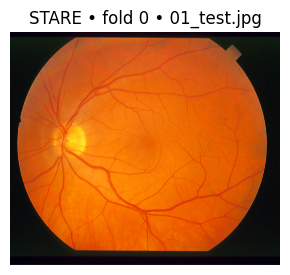

[F00 E001] train=0.3890 val=4.0574 lr=1.20e-04 time=31.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\UNet_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth
[F00 E002] train=0.2509 val=1.5532 lr=1.80e-04 time=56.4s
	CHECKPOINT SAVED: ..\..\..\..\pth\UNet_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth
[F00 E003] train=0.1962 val=2.4404 lr=2.40e-04 time=50.6s
[F00 E004] train=0.2066 val=1.2526 lr=3.00e-04 time=37.0s
	CHECKPOINT SAVED: ..\..\..\..\pth\UNet_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth
[F00 E005] train=0.2094 val=2.6119 lr=3.00e-04 time=50.9s
[F00 E006] train=0.1859 val=2.9051 lr=3.00e-04 time=35.8s
[F00 E007] train=0.1565 val=3.7086 lr=2.99e-04 time=31.8s
[F00 E008] train=0.1493 val=3.2640 lr=2.97e-04 time=32.0s
[F00 E009] train=0.1397 val=3.5142 lr=2.94e-04 time=32.2s
[F00 E010] train=0.1499 val=3.2815 lr=2.91e-04 time=46.9s
[F00 E011] train=0.1359 val=3.8773 lr=2.87e-04 time=55.9s
[F00 E012] train=0.1433 val=2.8873 lr=2.82e-04 time=55.9s
[F00 E013] train=0.1451 val=4.9447 lr=2.77e-04 time=

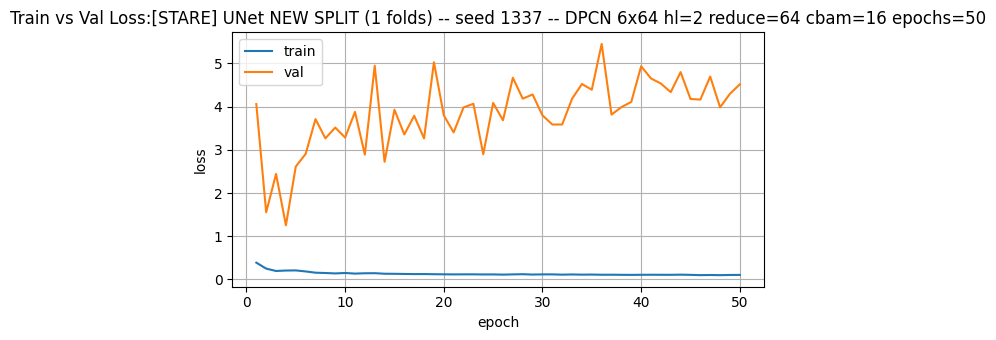

C:\Users\s1005\AppData\Local\Temp\ipykernel_26152\320207302.py:96: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=DEV

== [F00] 01_test == 
SEN=0.7841
SPE=0.9682
CLDICE=0.6827
ACC=0.9569
Dice=0.6907
IoU=0.5275
AUC=0.9761
== Predictions SAVED TO FILE: ..\..\..\..\pth\UNet_STARE_NEWSPLIT\predictions\01_test__fold00.pt ==


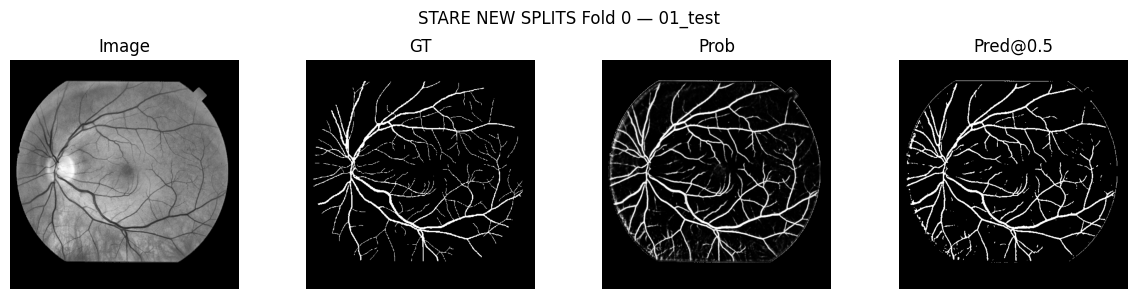


=== STARE NEW SPLITS (1 folds) — mean ± std ===
SEN: 0.7841 ± 0.0000
SPE: 0.9682 ± 0.0000
CLDICE: 0.6827 ± 0.0000
ACC: 0.9569 ± 0.0000
Dice: 0.6907 ± 0.0000
IoU: 0.5275 ± 0.0000
AUC: 0.9761 ± 0.0000
AP: 0.7846 ± 0.0000


In [ ]:
all_metrics, summary = run_stare_loo_experiment(
    root=DATASET_ROOT,
    label_folder=DATASET_LABELFOLDER,
    epochs=EPOCHS,
    warmup=warmup_epochs,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    patch_train=True,
    patch_size=PATCH_SIZE,
    vessel_bias_p=VESSEL_BIAS,
    threshold_eval=THRESHOLD_EVAL,
    folds=FOLDS,
    fold_id=FOLD_ID,   #starts at any fold_id

    chckpnt_paths= [
        # "..\..\..\..\pth\FR-UNet_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth",
        # "..\..\..\..\pth\FR-UNet_STARE_NEWSPLIT\checkpoints\STARE_fold01.pth"

    ]
)
